In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
r_bin_edges = [0, 1, 2]
theta_bin_edges = [np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4]

x_bin_edges = []
y_bin_edges = []

for r in r_bin_edges:
    for theta in theta_bin_edges:
        x_bin_edges.append(r * np.cos(theta))
        y_bin_edges.append(r * np.sin(theta))

In [76]:
x_bin_edges

[np.float64(-0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(-0.0),
 np.float64(-0.7071067811865475),
 np.float64(0.7071067811865476),
 np.float64(0.7071067811865476),
 np.float64(-0.7071067811865475),
 np.float64(-1.414213562373095),
 np.float64(1.4142135623730951),
 np.float64(1.4142135623730951),
 np.float64(-1.414213562373095)]

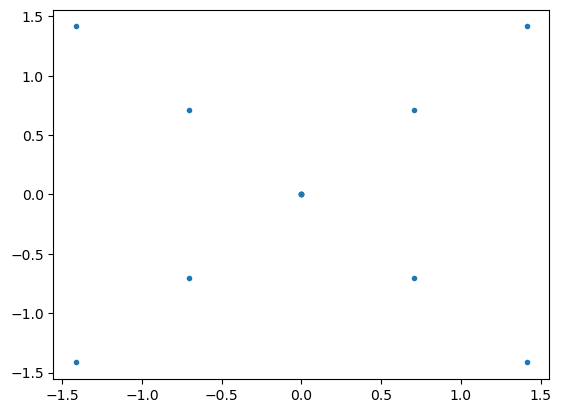

In [77]:
plt.plot(x_bin_edges, y_bin_edges, '.')

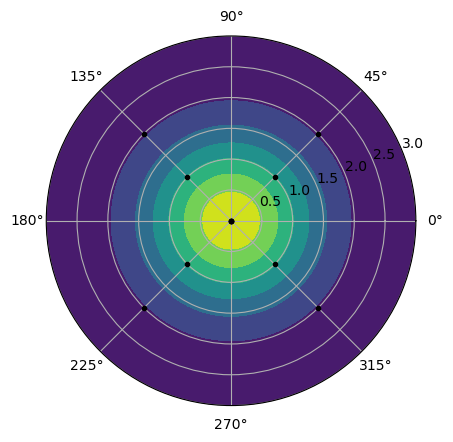

In [84]:
r = np.linspace(0, 3, 100)
theta = np.linspace(0, 2*np.pi, 100)
R, Theta = np.meshgrid(r, theta)
Z = np.exp(-R**2 / (2 * 1.0**2))  # Gaussian with sigma=1

polar_gridpts = np.array([(theta, r) for r in r_bin_edges for theta in theta_bin_edges])

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
# fig, ax = plt.subplots(1, 1)
plt.plot(polar_gridpts[:, 0], polar_gridpts[:, 1], '.k')
ax.contourf(Theta, R, Z)
plt.show()



In [130]:
from scipy import integrate

def integrand(r, theta):
    return np.exp(-r**2/2) * r 

binned_avgs = np.zeros((len(r_bin_edges)-1, len(theta_bin_edges)))

r_bin_centers = np.zeros(len(r_bin_edges)-1)
theta_bin_centers = np.zeros(len(theta_bin_edges))

for i in range(len(r_bin_edges)-1):
    for j in range(len(theta_bin_edges)):
        r_bin_centers[i] = (r_bin_edges[i] + r_bin_edges[i+1])/2.
        theta_bin_centers[j] = (theta_bin_edges[j] + theta_bin_edges[(j+1)%len(theta_bin_edges)])/2.
        result, error = integrate.dblquad(integrand, theta_bin_edges[j], theta_bin_edges[(j+1)%len(theta_bin_edges)], lambda r:r_bin_edges[i], lambda r: r_bin_edges[i+1])

        binned_avgs[i, j] = result

        print(r_bin_edges[i], r_bin_edges[i+1])

theta_bin_centers[-1] = (theta_bin_edges[-1] + theta_bin_edges[0] + 2*np.pi)/2.
binned_avgs[0, -1], error = integrate.dblquad(integrand, theta_bin_edges[-1], theta_bin_edges[0] + 2*np.pi, lambda r:r_bin_edges[0], lambda r: r_bin_edges[1])
binned_avgs[1, -1], error = integrate.dblquad(integrand, theta_bin_edges[-1], theta_bin_edges[0] + 2*np.pi, lambda r:r_bin_edges[1], lambda r: r_bin_edges[2])

0 1
0 1
0 1
0 1
1 2
1 2
1 2
1 2


In [ ]:
theta_bin_edges[-1]

5.497787143782138

In [112]:
theta_bin_edges[0]

0.7853981633974483

In [113]:
(theta_bin_edges[0] + theta_bin_edges[-1])

6.283185307179586

In [103]:
binned_avgs

array([[0.61806019, 0.61806019, 0.61806019, 0.        ],
       [0.        , 0.        , 0.        , 0.        ]])

In [109]:
binned_avgs = np.zeros((len(r_bin_edges)-1, len(theta_bin_edges)))

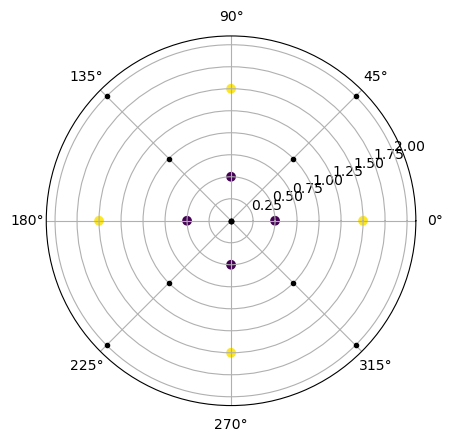

In [154]:
bin_edges = np.array([(theta, r) for r in r_bin_edges for theta in theta_bin_edges])

bin_centers = []

for i in range(len(r_bin_centers)):
    for j in range(len(theta_bin_centers)):
        bin_centers.append([r_bin_centers[i], theta_bin_centers[j]])

bin_centers = np.array(bin_centers)

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'})

ax.plot(bin_edges[:, 0], bin_edges[:, 1], '.k')

ax.scatter(bin_centers[:, 1], bin_centers[:, 0], c=binned_avgs)
plt.show()

In [146]:
bin_centers[:, 0]

TypeError: list indices must be integers or slices, not tuple

In [150]:
result, error = integrate.dblquad(integrand, np.pi/4, 3*np.pi/4, lambda r:1, lambda r:2)

In [151]:
result

0.7401519665712718

In [143]:
bin_centers

[[np.float64(0.5), np.float64(1.5707963267948966)],
 [np.float64(0.5), np.float64(3.141592653589793)],
 [np.float64(0.5), np.float64(4.71238898038469)],
 [np.float64(0.5), np.float64(6.283185307179586)],
 [np.float64(1.5), np.float64(1.5707963267948966)],
 [np.float64(1.5), np.float64(3.141592653589793)],
 [np.float64(1.5), np.float64(4.71238898038469)],
 [np.float64(1.5), np.float64(6.283185307179586)]]

In [132]:
binned_avgs

array([[0.61806019, 0.61806019, 0.61806019, 0.61806019],
       [0.74015197, 0.74015197, 0.74015197, 0.74015197]])

In [193]:
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)

X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
THETA = np.arctan2(Y, X)

In [153]:
R

array([[2.82842712, 2.23606798, 2.        , 2.23606798, 2.82842712],
       [2.23606798, 1.41421356, 1.        , 1.41421356, 2.23606798],
       [2.        , 1.        , 0.        , 1.        , 2.        ],
       [2.23606798, 1.41421356, 1.        , 1.41421356, 2.23606798],
       [2.82842712, 2.23606798, 2.        , 2.23606798, 2.82842712]])

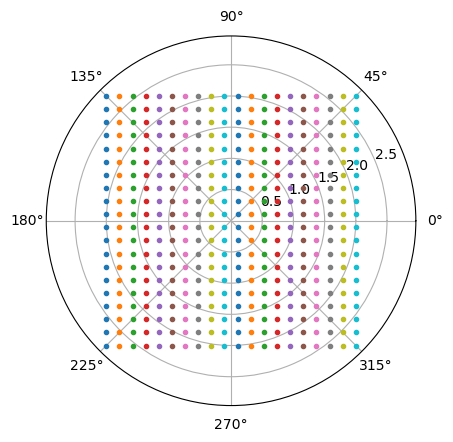

In [194]:
fig, axs = plt.subplots(subplot_kw={'projection': 'polar'})
plt.plot(THETA, R, '.')

In [159]:
bin_centers

array([[0.5       , 1.57079633],
       [0.5       , 3.14159265],
       [0.5       , 4.71238898],
       [0.5       , 6.28318531],
       [1.5       , 1.57079633],
       [1.5       , 3.14159265],
       [1.5       , 4.71238898],
       [1.5       , 6.28318531]])

In [158]:
mapped_vals = np.zeros((len(x), len(y)))

In [195]:
# Convert the polar bin centers to cartesian
cart_bin_centers = np.zeros((len(bin_centers), 2))
for i in range(len(bin_centers)):
    cart_bin_centers[i] = [bin_centers[i, 0] * np.cos(bin_centers[i, 1]), bin_centers[i, 0] * np.sin(bin_centers[i, 1])]

In [196]:
# Associate the binned values in polar coordinates to the Cartesian bin centers

cartesian_vals = np.zeros(len(bin_centers))

for i in range(len(r_bin_centers)):
    for j in range(len(theta_bin_centers)):
        m = i*len(theta_bin_centers) + j
        cartesian_vals[m] = binned_avgs[i, j]

In [184]:
cartesian_vals

array([0.61806019, 0.61806019, 0.61806019, 0.61806019, 0.74015197,
       0.74015197, 0.74015197, 0.74015197])

In [162]:
cart_bin_centers

array([[ 3.06161700e-17,  5.00000000e-01],
       [-5.00000000e-01,  6.12323400e-17],
       [-9.18485099e-17, -5.00000000e-01],
       [ 5.00000000e-01, -1.22464680e-16],
       [ 9.18485099e-17,  1.50000000e+00],
       [-1.50000000e+00,  1.83697020e-16],
       [-2.75545530e-16, -1.50000000e+00],
       [ 1.50000000e+00, -3.67394040e-16]])

In [197]:
#Compute the nearest coordinate

nearest_coords = np.zeros((len(x), len(y)))

for i in range(len(x)):
    for j in range(len(y)):
        min_dist = (cart_bin_centers[m, 0] - x[i])**2 + (cart_bin_centers[m, 1] - y[j])**2
        min_m = 0
        for m in range(len(cart_bin_centers)):
            dist = (cart_bin_centers[m, 0] - x[i])**2 + (cart_bin_centers[m, 1] - y[j])**2
            print(dist)
            if dist<min_dist:
                min_dist = dist
                min_m = m

        nearest_coords[i, j] = min_m


10.25
6.25
6.25
10.25
16.25
4.25
4.249999999999999
16.25
9.241689750692522
5.452216066481995
5.662742382271468
9.452216066481993
14.820637119113576
3.4522160664819954
4.083795013850414
15.452216066481993
8.322022160664819
4.7430747922437675
5.164127423822714
8.743074792243767
13.479916897506925
2.743074792243768
4.006232686980608
14.743074792243766
7.490997229916898
4.122576177285318
4.75415512465374
8.122576177285318
12.227839335180054
2.1225761772853193
4.01731301939058
14.122576177285318
6.748614958448753
3.5907202216066483
4.432825484764543
7.590720221606648
11.064404432132964
1.5907202216066487
4.117036011080332
13.590720221606647
6.0948753462603875
3.1475069252077565
4.200138504155125
7.147506925207756
9.989612188365651
1.1475069252077568
4.30540166204986
13.147506925207756
5.529778393351801
2.792936288088643
4.056094182825484
6.792936288088643
9.003462603878116
0.7929362880886431
4.582409972299168
12.792936288088642
5.053324099722992
2.5270083102493075
4.000692520775623
6.527008

In [198]:
nearest_coords

array([[6., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5.],
       [6., 6., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 4.],
       [6., 6., 6., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 4., 4.],
       [6., 6., 6., 6., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 4., 4., 4.],
       [6., 6., 6., 6., 6., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        4., 4., 4., 4.],
       [6., 6., 6., 6., 6., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 4.,
        4., 4., 4., 4.],
       [6., 6., 6., 6., 6., 2., 2., 1., 1., 1., 1., 1., 1., 1., 0., 4.,
        4., 4., 4., 4.],
       [6., 6., 6., 6., 6., 2., 2., 2., 1., 1., 1., 1., 1., 0., 0., 4.,
        4., 4., 4., 4.],
       [6., 6., 6., 6., 6., 2., 2., 2., 2., 1., 1., 1., 0., 0., 0., 4.,
        4., 4., 4., 4.],
       [6., 6., 6., 6., 6., 2., 2., 2., 2., 2., 1., 0., 0., 0., 0., 4.,
        4., 4., 4., 4.],
       [6., 6., 6., 6., 6., 2.

In [199]:
cart_interpolated = np.zeros(nearest_coords.shape)

In [200]:
for i in range(len(x)):
    for j in range(len(x)):
        cart_interpolated[i, j] = cartesian_vals[int(nearest_coords[i, j])]

In [201]:
cart_interpolated

array([[0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197],
       [0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197],
       [0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197],
       [0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0.74015197, 0.74015197,
        0.74015197, 0.74015197, 0.74015197, 0

In [191]:
x

array([-2., -1.,  0.,  1.,  2.])

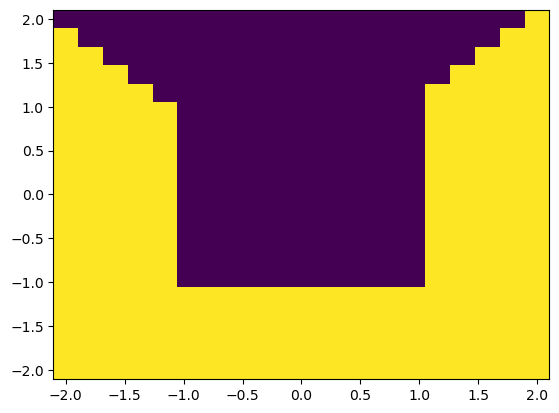

In [202]:
plt.pcolormesh(X, Y, cart_interpolated)